In [1]:
import pandas as pd
import numpy as np

pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
# Load dictionary from pickle file
import pickle
with open('../Data/sentiment_dict.pickle', 'rb') as handle:
    sentiment_dict = pickle.load(handle)

In [3]:
sentiment_dict['TESLA']['negative']

,id,created_at,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,text_length,day,processed_text,finbert_sentiment,month,tweetbert_sentiment,vader_sentiment
415,1645163173505277952,2023-04-09T20:34:00.000Z,@DavidSacks @VivekGRamaswamy @GregAbbott_TX Ye...,[],"[DavidSacks, VivekGRamaswamy, GregAbbott_TX]",[],True,714,371,7970,58,465688,44,2023-04-09,yeah wrong mani level tesla product rapid ...,neutral,2023,negative,neutral
786,1640976072908103681,2023-03-29T07:15:58.000Z,@george__mack I thought both SpaceX and Tesla ...,[],[george__mack],[],True,2249,3693,34574,275,4313610,16,2023-03-29,spacex tesla less chanc success,neutral,2023,negative,neutral
1688,1629251610135220226,2023-02-24T22:47:08.000Z,"@RalphNader Ralph Nader, you are lying – shame...",[],[RalphNader],[],True,22668,11250,287631,1543,21505594,57,2023-02-24,ralph nader shame person almost tesla fu...,neutral,2023,negative,neutral
2245,1621298953819131905,2023-02-03T00:06:07.000Z,@WholeMarsBlog Sucks that I had to sell so muc...,[],[WholeMarsBlog],[],True,893,2386,16318,180,614193,15,2023-02-03,suck much tesla stock sigh,neutral,2023,negative,neutral
2600,1616134378064859136,2023-01-19T18:03:56.000Z,@teslaownersSV @Tesla @Ford @Rivian @LucidMoto...,[],"[teslaownersSV, Tesla, Ford, Rivian, LucidMotors]",[],True,1531,1359,20163,137,3145155,21,2023-01-19,fed rate increas car expens difficulti level a...,neutral,2023,negative,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,337795753797898240,2013-05-24T05:02:38.000Z,@SapientCapital We created electric cars to he...,[],[SapientCapital],[],True,11,9,30,0,0,20,2013-05-24,electr car problem easi money still n,negative,2013,negative,neutral
23608,321342187067543552,2013-04-08T19:22:02.000Z,Sarah Palin calls Tesla a loser. Am deeply wou...,[],[],[],False,379,291,183,3,0,17,2013-04-08,sarah palin tesla loser deepli btw model...,neutral,2013,negative,neutral
23734,299779101366030336,2013-02-08T07:18:02.000Z,"No, they are not “@AutoblogGreen: Are electric...",[],[Reuters],[],False,94,37,55,0,0,17,2013-02-08,autobloggreen electr vehicl realli dead ...,neutral,2013,negative,neutral
23766,278910105804734464,2012-12-12T17:12:05.000Z,"Tesla articles 30 mins apart: ""This Stock is S...",[],[],[],False,57,33,50,3,0,18,2012-12-12,tesla min apart stock buy stock could ...,neutral,2012,negative,neutral


In [4]:
tweets_df = pd.read_parquet('../Data/tweet_data.parquet')

In [5]:
# Tesla, Bitcoin, Doge, Ethereum => keywords for each one of them
keywords = {
    'tesla': ['tesla', 'tsla', 'electric', 'car', 'autopilot', 'gigafactory', 'model s', 'model y', 'model 3', 'model x', 'roadster' , 'cybetruck', ],
    'bitcoin': ['bitcoin', 'btc', 'satoshi','nakamoto'],
    'doge': ['doge', 'dogecoin', 'meme coin'],
    'ethereum': ['ethereum', ' eth ', 'vitalik', 'buterin'],
}

In [6]:
# Add a column with the security that the tweet is about
tweets_df['security'] = tweets_df['text'].apply(lambda x: [k for k in keywords.keys() if any([kw in x.lower() for kw in keywords[k]])])

In [7]:
import datetime as dt
start_date = "2010-01-01"
end_date = "2023-01-01"


tweets_df = tweets_df[(tweets_df['created_at'] <= end_date) & (tweets_df['created_at'] >= start_date)]
tweets_df['created_at'] = pd.to_datetime(tweets_df['created_at']).dt.date


tweets_df_categorized = tweets_df[tweets_df['security'].apply(lambda x: len(x) > 0)]
tweets_df_categorized = tweets_df_categorized.explode('security') # explode to get one row per tweet on a subject



tweets_df_categorized.set_index('created_at', inplace=True)

tweets_df_categorized

,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security
created_at,,,,,,,,,,,,
2022-12-31,1609312363530031107,@jpr007 I’d like to thank the people of Norway...,[],[jpr007],[],True,1980,1736,50997,171,10824637,tesla
2022-12-31,1609057577236561920,@WholeMarsBlog Tesla Megapack (and Powerwall) ...,[],[WholeMarsBlog],[],True,1082,1103,13904,84,2688029,tesla
2022-12-30,1608959010228822017,@teslaownersSV It’s good to switch back &amp; ...,[],[teslaownersSV],[],True,473,461,6593,67,534652,tesla
2022-12-30,1608956890528256000,@teslaownersSV @Tesla Long-term fundamentals a...,[],"[teslaownersSV, Tesla]",[],True,1931,1146,22469,246,8957234,tesla
2022-12-30,1608925658562060288,"@cb_doge @BillyM2k Yeah, icon placement &amp; ...",[],"[cb_doge, BillyM2k]",[],True,124,159,2066,5,200638,doge
...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-31,153099684280410112,Hacked my Tesla charge connector on a small is...,[whatcouldpossiblygowrong],[],[],False,36,51,383,15,0,tesla
2011-12-28,152154308710899713,RT @TheOnion: Any Idiot Could Have Come Up Wit...,[OnionInnovation],[TheOnion],[],True,51,0,0,0,0,tesla
2011-12-22,149813972915339264,Model S options are out! Performance in red an...,[],[],[],False,83,52,848,16,0,tesla


In [8]:
import sys

MODULES_PATH = "../modules"
if MODULES_PATH not in sys.path:
    sys.path.append(MODULES_PATH)

from assets_etl import *

In [9]:

# Download the stock data
import yfinance as yf



ticker_names = ['BTC-USD', 'DOGE-USD', 'ETH-USD']
securities_dict = {}

# open the tesla data that was downloaded and pre-processed with wrds-loader
df = pd.read_csv("../Data/securities/TSLA_2010_2022.csv")
df['date'] = pd.to_datetime(df['date'])
df = linear_interpolation(df, cols=['ret'])

# compute log returns
df['log_return'] = np.log(1 + df['ret'])
df.rename(columns={'index': 'Date'}, inplace=True)
df.drop(columns=['permno'], inplace=True)
df.set_index('Date', inplace=True)
securities_dict['tesla'] = df

# Download the crypto data
for ticker in ticker_names:
    yf.download(ticker, start=start_date, end=end_date,
                progress=False, interval="1d").to_csv("../Data/securities/BTC-USD.csv")


    df = pd.read_csv(f"../Data/securities/{ticker}.csv")
    df['ret'] = df['Adj Close'].pct_change()
    df['log_return'] = np.log(1 + df['ret'])

    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    display(df.head())

    name = ""
    if ticker == 'BTC-USD':
        name = 'bitcoin'
    elif ticker == 'DOGE-USD':
        name = 'doge'
    elif ticker == 'ETH-USD':
        name = 'ethereum'

    securities_dict[name] = df


,Open,High,Low,Close,Adj Close,Volume,ret,log_return
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,-0.071926,-0.074643
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,-0.069843,-0.072402
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,0.035735,0.035111
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,-0.024659,-0.024968


,Open,High,Low,Close,Adj Close,Volume,ret,log_return
Date,,,,,,,,
2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550,NaN,NaN
2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520,-0.178092,-0.196127
2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080,0.032674,0.032152
2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960,-0.135720,-0.145859
2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270,0.166667,0.154151


,Open,High,Low,Close,Adj Close,Volume,ret,log_return
Date,,,,,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984,NaN,NaN
2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984,-0.067411,-0.069790
2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992,0.051555,0.050270
2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936,-0.021523,-0.021758
2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984,0.028606,0.028204


In [10]:
from datetime import timedelta

windowed_returns_dict = {}
pre_effect_window = 14
post_effect_window = 8

for security in securities_dict.keys():
    
    tweets_subset_df = tweets_df_categorized[tweets_df_categorized['security'] == security]
    prices_df = securities_dict[security]

    tweets_subset_df['log_returns_before_tweet'] = tweets_subset_df.index.map(
        lambda x: prices_df.loc[x - timedelta(days=pre_effect_window): x - timedelta(days=1)]['log_return'].values)

    tweets_subset_df['log_returns_after_tweet'] = tweets_subset_df.index.map(
        lambda x: prices_df.loc[x: x + timedelta(days=post_effect_window - 1)]['log_return'].values)
    
    windowed_returns_dict[security] = tweets_subset_df


In [11]:
# perform t-test on the returns/prices before and after the tweet
from scipy.stats import ttest_ind

for security in windowed_returns_dict.keys():
    
    current_df = windowed_returns_dict[security]

    display(current_df.head())

    current_df['t_stat'] = current_df.apply(lambda x: ttest_ind(x['log_returns_before_tweet'], x['log_returns_after_tweet']), axis=1)
    current_df['p_value'] = current_df['t_stat'].apply(lambda x: x[1])
    current_df['t_stat'] = current_df['t_stat'].apply(lambda x: x[0])    



,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet
created_at,,,,,,,,,,,,,,
2022-12-31,1609312363530031107,@jpr007 I’d like to thank the people of Norway...,[],[jpr007],[],True,1980,1736,50997,171,10824637,tesla,"[-0.032788615503700075, -0.017478475446652354,...",[]
2022-12-31,1609057577236561920,@WholeMarsBlog Tesla Megapack (and Powerwall) ...,[],[WholeMarsBlog],[],True,1082,1103,13904,84,2688029,tesla,"[-0.032788615503700075, -0.017478475446652354,...",[]
2022-12-30,1608959010228822017,@teslaownersSV It’s good to switch back &amp; ...,[],[teslaownersSV],[],True,473,461,6593,67,534652,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296]
2022-12-30,1608956890528256000,@teslaownersSV @Tesla Long-term fundamentals a...,[],"[teslaownersSV, Tesla]",[],True,1931,1146,22469,246,8957234,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296]
2022-12-30,1608777424011137027,@universal_sci Carbs rock,[],[universal_sci],[],True,855,1927,21790,165,5348470,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296]


/tmp/ipykernel_1460975/1034316910.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  current_df['t_stat'] = current_df.apply(lambda x: ttest_ind(x['log_returns_before_tweet'], x['log_returns_after_tweet']), axis=1)
/home/adeye/anaconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in true_divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/adeye/anaconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in double_scalars
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet
created_at,,,,,,,,,,,,,,
2022-12-08,1600783739633643521,@EthanBitcoin @dergigi lol,[],"[EthanBitcoin, dergigi]",[],True,290,322,8372,24,0,bitcoin,"[-0.00037586363225689277, -0.00498837489510304...","[0.022614200081039638, -0.005838370505888547, ..."
2022-11-14,1592043719645356034,"@dawallach @Jason BTC will make it, but might ...",[],"[dawallach, Jason]",[],True,5260,2408,27279,1055,0,bitcoin,"[-0.006799218852899474, -0.0005124320157945651...","[0.016064732404599078, 0.01590431717951544, -0..."
2022-11-11,1591091017213939714,"@BTC_Archive Needs some tweaks, but overall pr...",[],[BTC_Archive],[],True,1152,2164,28168,196,0,bitcoin,"[0.015142492579417856, 0.010775490653264773, -...","[-0.03191845360130116, -0.013898139747380939, ..."
2022-07-02,1543051160935874561,@BitcoinStripper Talulah designed that dress h...,[],[BitcoinStripper],[],True,248,444,7046,42,0,bitcoin,"[-0.07366571122488891, 0.07765301952407, 0.002...","[-0.0014079558563739067, 0.0028449039765122944..."
2022-05-01,1520657179908448258,@pmarca Haha he says “Bitcoin” so many times,[],[pmarca],[],True,1913,1860,28360,174,0,bitcoin,"[-0.017657522881942136, 0.027546268364385663, ...","[0.019800580200401846, 0.0015645616058173508, ..."


,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet
created_at,,,,,,,,,,,,,,
2022-12-30,1608925658562060288,"@cb_doge @BillyM2k Yeah, icon placement &amp; ...",[],"[cb_doge, BillyM2k]",[],True,124,159,2066,5,200638,doge,"[-0.1094053567764542, 0.04285201363354617, -0....","[-0.03784001731771635, 0.027255197950431773, -..."
2022-12-30,1608906102271520768,@cb_doge @ScottAdamsSays Not enough,[],"[cb_doge, ScottAdamsSays]",[],True,181,333,4523,20,256571,doge,"[-0.1094053567764542, 0.04285201363354617, -0....","[-0.03784001731771635, 0.027255197950431773, -..."
2022-12-28,1608191997768265728,@dogeofficialceo Accurate lol,[],[dogeofficialceo],[],True,987,816,25998,63,1231395,doge,"[-0.02703919969855149, -0.04378545632780046, -...","[-0.04640506357691488, 0.009347919559943636, -..."
2022-12-28,1608188746947493889,@dogeofficialceo @GadSaad 🤣,[],"[dogeofficialceo, GadSaad]",[],True,318,185,8156,12,448869,doge,"[-0.02703919969855149, -0.04378545632780046, -...","[-0.04640506357691488, 0.009347919559943636, -..."
2022-12-26,1607429323920924672,@cb_doge @BillyM2k 🤣,[],"[cb_doge, BillyM2k]",[],True,279,169,4960,11,233393,doge,"[-0.028582202671951294, 0.007527672077964345, ...","[-0.002227588746385247, -0.02754557210642131, ..."


,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet
created_at,,,,,,,,,,,,,,
2022-12-14,1602971117802881027,@conexaopolitica @VitalikButerin Twitter may h...,[],"[conexaopolitica, VitalikButerin]",[],True,2607,1276,15492,352,0,ethereum,"[0.06273462567793704, -0.015097452965501133, 0...","[-0.008533116264882437, -0.03337277794308664, ..."
2022-12-14,1602969877651783681,@SirGrantFleming @conexaopolitica @VitalikBute...,[],"[SirGrantFleming, conexaopolitica, VitalikBute...",[],True,121,87,2763,9,0,ethereum,"[0.06273462567793704, -0.015097452965501133, 0...","[-0.008533116264882437, -0.03337277794308664, ..."
2022-12-14,1602953261547503617,@conexaopolitica @VitalikButerin Looking into ...,[],"[conexaopolitica, VitalikButerin]",[],True,426,168,6939,25,0,ethereum,"[0.06273462567793704, -0.015097452965501133, 0...","[-0.008533116264882437, -0.03337277794308664, ..."
2022-12-14,1602886199181393920,@VitalikButerin https://t.co/PwnIrTf1Ej,[],[VitalikButerin],[],True,1036,1492,34872,139,0,ethereum,"[0.06273462567793704, -0.015097452965501133, 0...","[-0.008533116264882437, -0.03337277794308664, ..."
2022-10-25,1584898685736869888,@VitalikButerin @balajis @zengjiajun_eth Had t...,[],"[VitalikButerin, balajis, zengjiajun_eth]",[],True,530,901,11400,58,0,ethereum,"[-0.009150090604978236, 0.011909867196354756, ...","[0.08318355022278977, 0.06930990366099622, -0...."


In [12]:
# compute the percentage of significant p-values for each security 

with open('results.txt', 'a') as f:
    f.write(f'For Window Size: {pre_effect_window} days before and {post_effect_window} days after\n')
    for security in windowed_returns_dict.keys():
        current_df = windowed_returns_dict[security]
        print(f"Percentage of significant p-values for {security}: {np.mean(current_df['p_value'] < 0.05)}")
        f.write(f"Percentage of significant p-values for {security}: {np.mean(current_df['p_value'] < 0.05)}\n")
    f.write('\n\n')

Percentage of significant p-values for tesla: 0.18353311063077227
Percentage of significant p-values for bitcoin: 0.06896551724137931
Percentage of significant p-values for doge: 0.041474654377880185
Percentage of significant p-values for ethereum: 0.045454545454545456


In [13]:
windowed_returns_dict['tesla']

,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet,t_stat,p_value
created_at,,,,,,,,,,,,,,,,
2022-12-31,1609312363530031107,@jpr007 I’d like to thank the people of Norway...,[],[jpr007],[],True,1980,1736,50997,171,10824637,tesla,"[-0.032788615503700075, -0.017478475446652354,...",[],NaN,NaN
2022-12-31,1609057577236561920,@WholeMarsBlog Tesla Megapack (and Powerwall) ...,[],[WholeMarsBlog],[],True,1082,1103,13904,84,2688029,tesla,"[-0.032788615503700075, -0.017478475446652354,...",[],NaN,NaN
2022-12-30,1608959010228822017,@teslaownersSV It’s good to switch back &amp; ...,[],[teslaownersSV],[],True,473,461,6593,67,534652,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296],NaN,NaN
2022-12-30,1608956890528256000,@teslaownersSV @Tesla Long-term fundamentals a...,[],"[teslaownersSV, Tesla]",[],True,1931,1146,22469,246,8957234,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296],NaN,NaN
2022-12-30,1608777424011137027,@universal_sci Carbs rock,[],[universal_sci],[],True,855,1927,21790,165,5348470,tesla,"[-0.04833680524548253, -0.032788615503700075, ...",[0.011102160265657296],NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-12-31,153099684280410112,Hacked my Tesla charge connector on a small is...,[whatcouldpossiblygowrong],[],[],False,36,51,383,15,0,tesla,"[-0.017571809185184292, -0.013260988064220035,...","[-0.008677085932698884, -0.011426974612527863,...",2.951356,0.007893
2011-12-28,152154308710899713,RT @TheOnion: Any Idiot Could Have Come Up Wit...,[OnionInnovation],[TheOnion],[],True,51,0,0,0,0,tesla,"[-0.03173774650175665, 0.003149614071297193, -...","[-0.0021022945787868143, 0.007686945907338172,...",1.090941,0.288268
2011-12-22,149813972915339264,Model S options are out! Performance in red an...,[],[],[],False,83,52,848,16,0,tesla,"[-0.10150067771679458, 0.004844237655661195, -...","[0.00722810366864838, 0.004670357231781736, 0....",-2.981080,0.007384


In [14]:
df_temp = windowed_returns_dict['tesla']
df_temp = df_temp[df_temp['p_value'] < 0.05]
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', -1)
df_temp[['text', 'p_value', 'log_returns_before_tweet', 'log_returns_after_tweet']].head(5)



,text,p_value,log_returns_before_tweet,log_returns_after_tweet
created_at,,,,
2022-12-29,RT @Tesla: S3XY winter testing in New Zealand ...,0.024300,"[0.005533102175507607, -0.04833680524548253, -...","[0.07772640405081715, 0.011102160265657296]"
2022-12-29,@TeslaAIBot Thanks Optimus 🤖 ♥️,0.024300,"[0.005533102175507607, -0.04833680524548253, -...","[0.07772640405081715, 0.011102160265657296]"
2022-12-20,RT @Tesla: Every Tesla has an electronic power...,0.004127,"[-0.014519754857137872, -0.03267127298325752, ...","[-0.0839648416634755, -0.0016704490415595592, ..."
2022-12-20,RT @Tesla: Be your own utility with Solar &amp...,0.004127,"[-0.014519754857137872, -0.03267127298325752, ...","[-0.0839648416634755, -0.0016704490415595592, ..."
2022-12-20,RT @Tesla: We’ve completed 500k+ Solar Panel a...,0.004127,"[-0.014519754857137872, -0.03267127298325752, ...","[-0.0839648416634755, -0.0016704490415595592, ..."


****
[ 0.05776766 -0.00888996  0.00978768  0.01219611 -0.00305258 -0.00423226
 -0.00541334 -0.0065958   0.00747463 -0.04171544  0.02581777 -0.02697365
 -0.00051185  0.02526774  0.05039941  0.06747862  0.03621312  0.07651406
  0.08923401  0.1017942   0.11419859  0.12645099]
****
[ 0.02898274 -0.00927659  0.17182056  0.00614262 -0.0342032   0.06446762
 -0.00847846 -0.00844175  0.03364388 -0.01597824  0.02583526  0.05821415
 -0.00903823  0.07828514  0.00377518  0.02535216 -0.05966345 -0.10458524
  0.0178815  -0.05396976 -0.01614208 -0.00327054]
****
[ 0.0124406  -0.00627607 -0.0034629  -0.0174282  -0.00107485  0.00568538
  0.01718191 -0.00265638 -0.01794308  0.01391998 -0.00339868  0.00604903
  0.0108797  -0.01403408  0.0551828   0.14645606  0.05632317  0.08555072
  0.37117174 -0.03175636  0.07538658  0.11547631]
****
[-0.0240283  -0.03865462  0.07882398  0.01218811 -0.0135479   0.0224239
  0.03293883 -0.0160887  -0.00498773 -0.01411124  0.00071696  0.03713901
  0.04702036  0.01165628 -0.

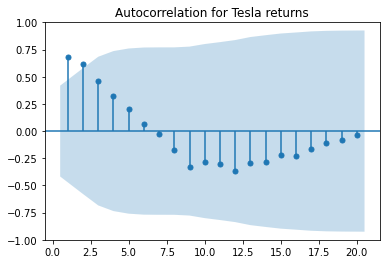

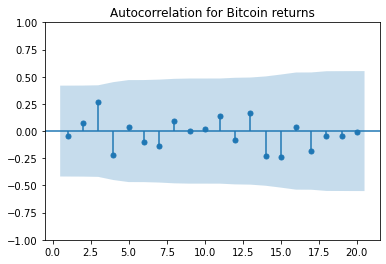

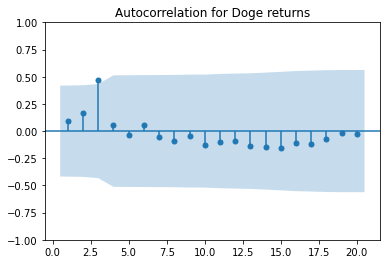

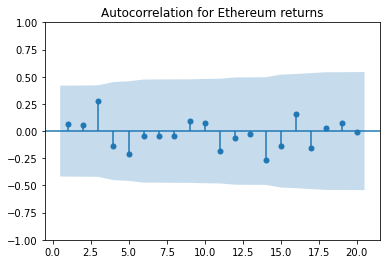

In [21]:
# For each security that we look at, we are going to take a few tweets that have a very small p-value and perform and autocorrelation test on the returns before and after the tweet
# If the autocorrelation is high, then we might have to use a different type of test to see if the returns are actually significant

from statsmodels.graphics.tsaplots import plot_acf
for security in securities_dict.keys():
    subset_df = windowed_returns_dict[security]
    subset_df_sorted = subset_df.sort_values(by='p_value', ascending=True)
    subset_df_sorted = subset_df_sorted[subset_df_sorted['p_value'] < 0.05]
    subset_df_sorted = subset_df_sorted.head(3)
    subset_df_sorted['all_returns'] = subset_df_sorted.apply(lambda x: np.concatenate((x['log_returns_before_tweet'], x['log_returns_after_tweet'])), axis=1)
    returns = subset_df_sorted['all_returns'].values

    print("****")
    print(returns[0])
    
    plot_acf(returns[0], lags=20, title=f"Autocorrelation for {security.capitalize()} returns", zero=False)


In [16]:
# The plots above seem to indicate that Tesla returns have tangible autocorrelation
# We are therefore going to use a different test to see if the returns are significant
import statsmodels.api as sm
from scipy import stats

current_df = windowed_returns_dict['tesla']
current_df = current_df[current_df.log_returns_after_tweet.apply(lambda x: len(x) >= post_effect_window)]

display(current_df.head())

def autocorrelation_ttest(row):

    before = row['log_returns_before_tweet']
    after = row['log_returns_after_tweet']

    ar_model_before = sm.tsa.AutoReg(before, lags=1)
    ar_model_after = sm.tsa.AutoReg(after, lags=1)

    ar_res_before = ar_model_before.fit().resid
    ar_res_after = ar_model_after.fit().resid 


    _, p_value = stats.mannwhitneyu(ar_res_before, ar_res_after, alternative='two-sided')

    return p_value


current_df['p_value_adjusted'] = current_df.apply(lambda x: autocorrelation_ttest(x), axis=1)

,id,text,hashtags,mentions,cashtags,is_reply,retweet_count,reply_count,like_count,quote_count,impression_count,security,log_returns_before_tweet,log_returns_after_tweet,t_stat,p_value
created_at,,,,,,,,,,,,,,,,
2022-12-23,1606347557071790080,RT @Tesla: Giga Texas is alive ⚡️🚘,[],[Tesla],[],True,3724,0,0,0,69,tesla,"[0.03183337965789328, 0.0006568087367956513, -...","[-0.017706675532212255, -0.04257901527098906, ...",-0.055038,0.956654
2022-12-23,1606342354096467973,@InspiredTesla @CryptoArch3 Agreed,[],"[InspiredTesla, CryptoArch3]",[],True,94,89,2455,6,232314,tesla,"[0.03183337965789328, 0.0006568087367956513, -...","[-0.017706675532212255, -0.04257901527098906, ...",-0.055038,0.956654
2022-12-22,1605995925339398145,Congratulations Tesla Team!! https://t.co/GMYM...,[],[],[],True,10931,9660,172043,667,27460407,tesla,"[-0.0034533869894747575, 0.03183337965789328, ...","[-0.0930231189665288, -0.017706675532212255, -...",0.866255,0.396624
2022-12-22,1605971794208337920,RT @Tesla: Track Mode coming to Model Y Perfor...,[],[Tesla],[],True,3475,0,0,0,64,tesla,"[-0.0034533869894747575, 0.03183337965789328, ...","[-0.0930231189665288, -0.017706675532212255, -...",0.866255,0.396624
2022-12-22,1605868203158011905,@teslaownersSV Should we keep it going?,[],[teslaownersSV],[],True,775,1670,16543,80,5617711,tesla,"[-0.0034533869894747575, 0.03183337965789328, ...","[-0.0930231189665288, -0.017706675532212255, -...",0.866255,0.396624


In [17]:
current_df[current_df['p_value_adjusted'] < 0.1]['text'].values

array(['@TesLatino @Erdayastronaut @NotEricRalph @MartianDays @torybruno @AerojetRdyne @elon Both at the same time!',
       '@robfarago @Tesla Do EV owners use V to G a lot in Australia?',
       '@CapnJesus @Lurpatron @MKBHD @jakerawr 3 is a great car, but definitely Model S',
       'RT @ID_AA_Carmack: @elonmusk @BadAstronomer We actually are outside some of the IPCC prediction ranges from 20 years ago http://t.co/WOLZlZ…',
       'RT @LeilaniMunter: Dear Oil, I am breaking up with you... http://t.co/D0cxsW6yt1 --- @TeslaMotors @elonmusk @TeslaMotorsClub'],
      dtype=object)